 Entraînement du modèle DQN...
 Modèle entraîné et sauvegardé !

 Évaluation du modèle...
Récompense moyenne sur 100 épisodes : 499.46 +/- 3.91

 Génération du GIF...

 Aperçu du résultat :


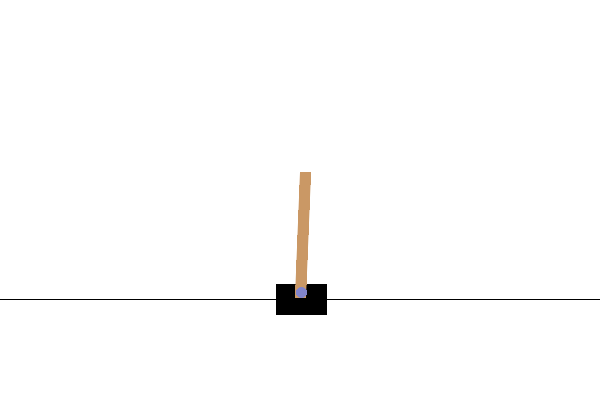

In [10]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
import imageio
from IPython.display import Image, display

# ============================
# CRÉATION DE L'ENVIRONNEMENT
# ============================
train_env = gym.make("CartPole-v1")
gif_env = gym.make("CartPole-v1", render_mode="rgb_array")

# ============================
# ENTRAÎNEMENT DU MODÈLE DQN
# ============================
print(" Entraînement du modèle DQN...")
model = DQN(
    policy="MlpPolicy",
    env=train_env,
    verbose=0,
    learning_rate=0.001,           # Learning rate
    buffer_size=50000,            # Taille du buffer de replay
    learning_starts=1000,         # Commence à apprendre après 1000 steps
    target_update_interval=500,   # Met à jour le réseau cible tous les 500 steps
    exploration_fraction=0.1,     # Explore pendant 10% du temps total
    tensorboard_log="./logs_dqn/"
)

model.learn(total_timesteps=75000)
model.save("dqn_cartpole")
print(" Modèle entraîné et sauvegardé !")

# ============================
# ÉVALUATION
# ============================
print("\n Évaluation du modèle...")
mean_reward, std_reward = evaluate_policy(
    model, 
    gif_env, 
    n_eval_episodes=100,
    warn=False  # évite les warnings
)
print(f"Récompense moyenne sur 100 épisodes : {mean_reward:.2f} +/- {std_reward:.2f}")

# ============================
# GÉNÉRATION DU GIF
# ============================
print("\n Génération du GIF...")
frames = []
n_episodes = 3
max_steps = 500

for ep in range(n_episodes):
    obs, info = gif_env.reset()
    for step in range(max_steps):
        frame = gif_env.render()
        frames.append(frame)
        
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = gif_env.step(action)
        
        if terminated or truncated:
            break

gif_path = "dqn_cartpole_preview.gif"
imageio.mimsave(gif_path, frames, fps=30)
print("\n Aperçu du résultat :")
display(Image(filename=gif_path))

train_env.close()
gif_env.close()